# Comparação entre oque foi Empenhado e Pago (Por Subfunção)

Conforme pedido no README.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Encontrando o arquivo
raiz_do_projeto = Path.cwd().parent.parent
caminho_db = raiz_do_projeto / "dados_otimizados" / "dados_otimizados.parquet"

# Lendo o arquivo
df = pd.read_parquet(caminho_db)

In [2]:
# Removendo a notação científica nos valores numéricos do Jupyter Notebook
pd.set_option('display.float_format', '{:,.2f}'.format)


In [3]:
# Verificando quantas Subfunções existem:

checagem_subfuncoes = df[df["Função/Subfunção"] == "Subfunção"]

total_subfuncoes = checagem_subfuncoes["Conta"].nunique()
print(f"Quanditdade de subfunções únicas:{total_subfuncoes}")

print("\nLista de subfuncoes:")
print(checagem_subfuncoes["Conta"].unique())

Quanditdade de subfunções únicas:147

Lista de subfuncoes:
<ArrowStringArray>
[                      '01.031 - Ação Legislativa',
 '03.092 - Representação Judicial e Extrajudicial',
               '04.121 - Planejamento e Orçamento',
                    '04.122 - Administração Geral',
               '04.123 - Administração Financeira',
                       '04.124 - Controle Interno',
            '04.125 - Normatização e Fiscalização',
               '04.126 - Tecnologia da Informação',
                     '04.131 - Comunicação Social',
                           '06.181 - Policiamento',
 ...
      '28.842 - Refinanciamento da Dívida Externa',
                  '07.211 - Relações Diplomáticas',
                           '18.545 - Meteorologia',
             '19.571 - Desenvolvimento Científico',
                        'FU05 - Demais Subfunções',
   '08.242 - Assistência à Pessoa com Deficiência',
                       '05.153 - Defesa Terrestre',
             '08.241 - Assistênci

In [4]:
# Serão necessárias as colunas Conta, UF, Coluna, Função/Subfunção e Ano

df_filtrado = df[["Conta", "UF", "Coluna", "Valor", "Função/Subfunção", "Ano"]]

# Condições de filtro
condicao_funcao = df_filtrado["Função/Subfunção"] == "Subfunção"
condicao_estagios = df_filtrado["Coluna"].isin(["Despesas Empenhadas", "Despesas Pagas"])

# Aplicando os filtros
df_analise = df_filtrado[condicao_funcao & condicao_estagios]


Criada uma tabela dinâmica para melhor manipulação.

In [5]:
# Tabela dinâmica para agrupar os dados.
df_pivot = pd.pivot_table(
    df_analise, 
    index=["Conta", "UF", "Ano"],
    columns="Coluna",
    values="Valor",
    aggfunc="sum"
    ).reset_index()

# Adicionando uma coluna para calular a Taxa de Execução do valor (%).
df_pivot["Taxa de Execução"] = ((df_pivot["Despesas Pagas"] / df_pivot["Despesas Empenhadas"]) * 100).fillna(0).replace([np.inf, -np.inf], 0)


Criado um gráfico de barras horizontais para melhor visualização. Isso salvo em uma função para ser chamada em cada ano.

In [6]:
# Criando o gráfico
import seaborn as sns
import matplotlib.pyplot as plt

def grafico_menor_subfuncao (df, ano_desejado):
    """
    Filtra os dados por ano, isola as subfunções com maior diferença entre 
    o que foi empenhado e oque foi pago de cada capital, retornando um gráfico de barras horizontais.
    """

    # 1. Filtragem por ano
    df_ano = df[df["Ano"] == ano_desejado].copy()

    # Tratamento de erros.
    if df_ano.empty:
        print("⚠️ Nenhum ano selecionado.")
        return
    
    # 2. Isolamento da menor taxa de cada capital
    idx_minimos = df_ano.groupby("UF")["Taxa de Execução"].idxmin()
    df_diferenca_uf = df_ano.loc[idx_minimos].copy()

    # 3. Adicionando uma coluna de Taxa
    df_diferenca_uf["Taxa (%)"] = df_diferenca_uf["Taxa de Execução"]

    # 4. Rótulo combinado para o eixo 'Y'
    df_diferenca_uf["Capital e Subfunção"] = df_diferenca_uf["UF"] + " - " + df_diferenca_uf["Conta"]

    # 5. Ordem crescente
    df_diferenca_uf = df_diferenca_uf.sort_values(by="Taxa (%)", ascending=False)

    # 6. Proporções da imagem
    plt.figure(figsize=(14, 10))
    
    # 7. Gráfico de barras horizontais
    ax = sns.barplot(
        data=df_diferenca_uf,
        x="Taxa de Execução",
        y="Capital e Subfunção",
        palette="flare_r",
        hue="Capital e Subfunção",
        legend=False
    )

    # Porcentagem ao final de cada barra
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=5, fontsize=10)

    # 8. Estilização
    plt.title(f"A maior diferença orçamentária de cada capital em {ano_desejado}\n(Por Subfunção - Ordenado do maior ao menor)", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("Taxa entre Empenhado e Pago (%)", fontsize=12, labelpad=10)
    plt.ylabel("Capital e Área Crítica", fontsize=12, labelpad=10)
    plt.xlim(-5, 105)

    # Ajustando grid
    plt.grid(axis='x', linestyle='--', alpha=0.5)

    # Ajustando espaçamento do gráfico
    plt.tight_layout()

    # Mostrando o gráfico
    plt.show()

Chamando a função...

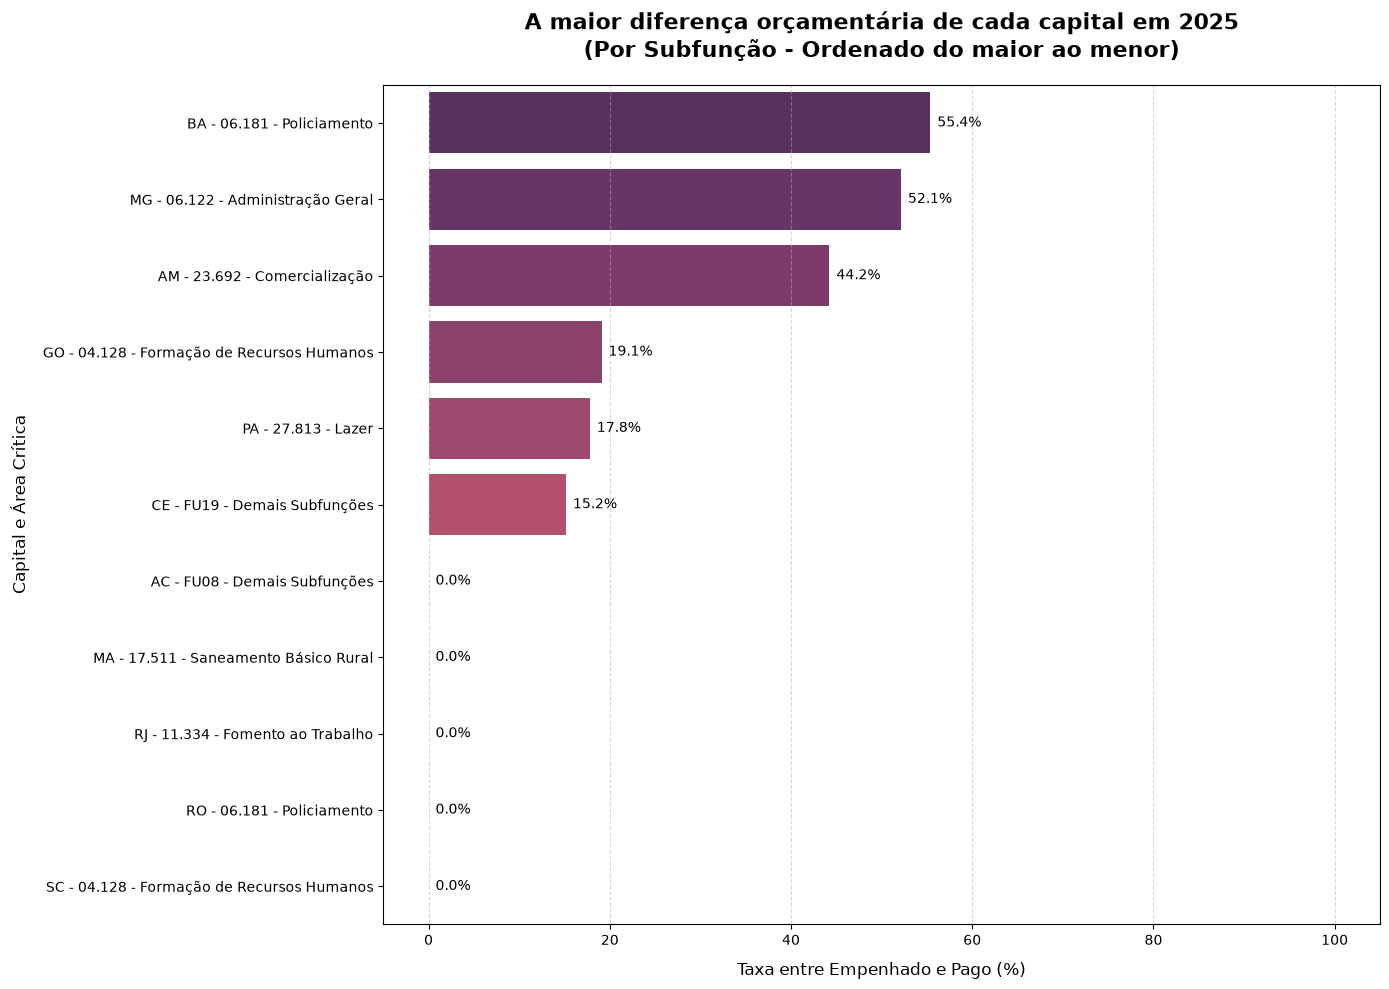

In [7]:
# Analisando o ano de 2025
grafico_menor_subfuncao(df_pivot, 2025)

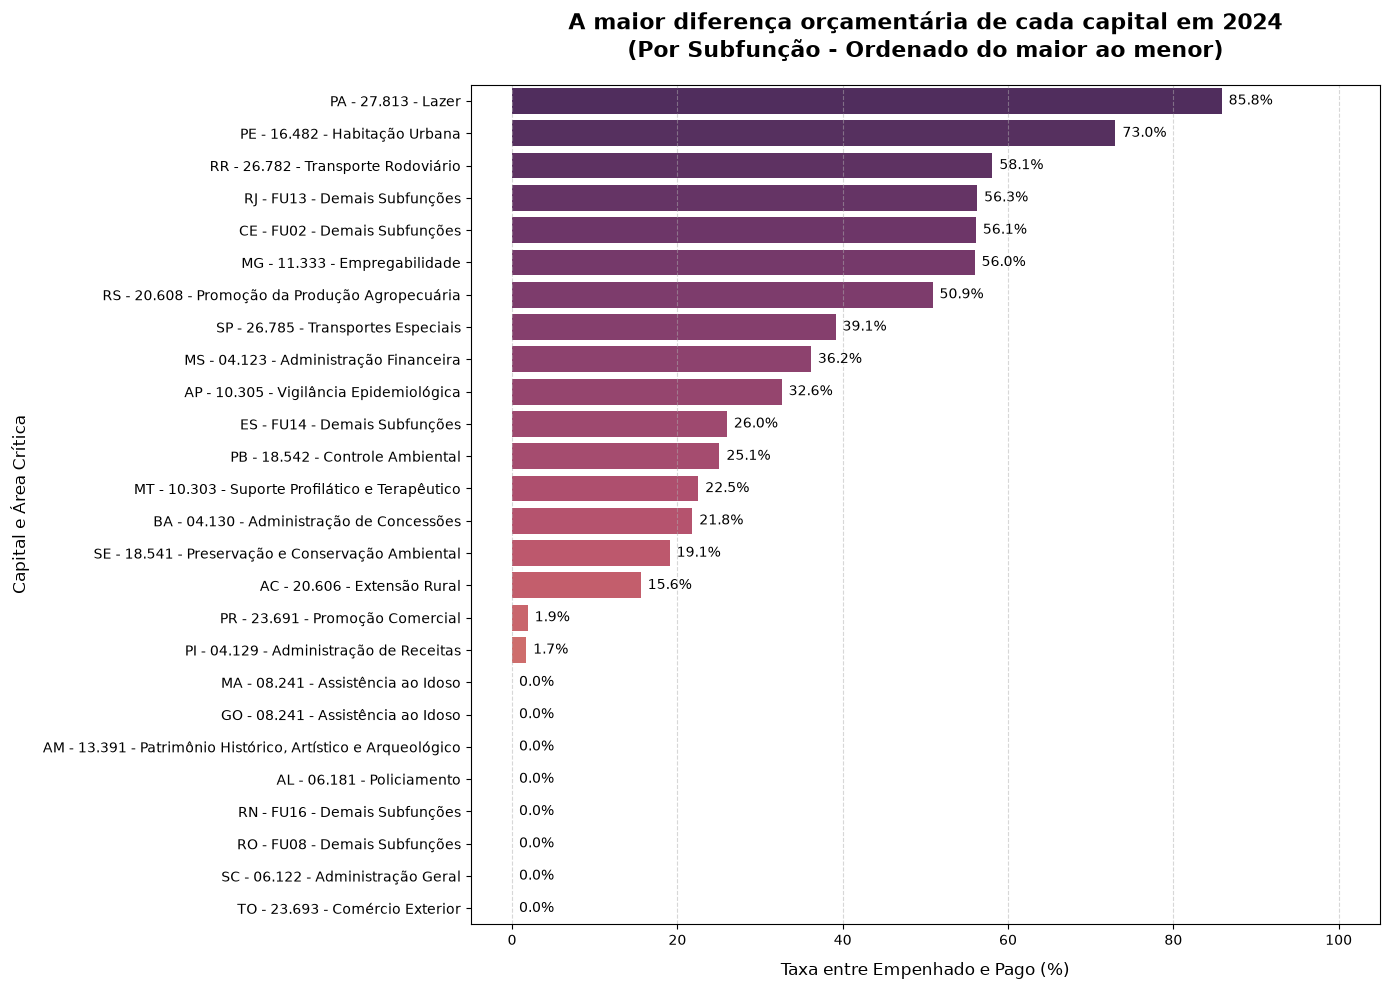

In [8]:
# Analisando o ano de 2024
grafico_menor_subfuncao(df_pivot, 2024)

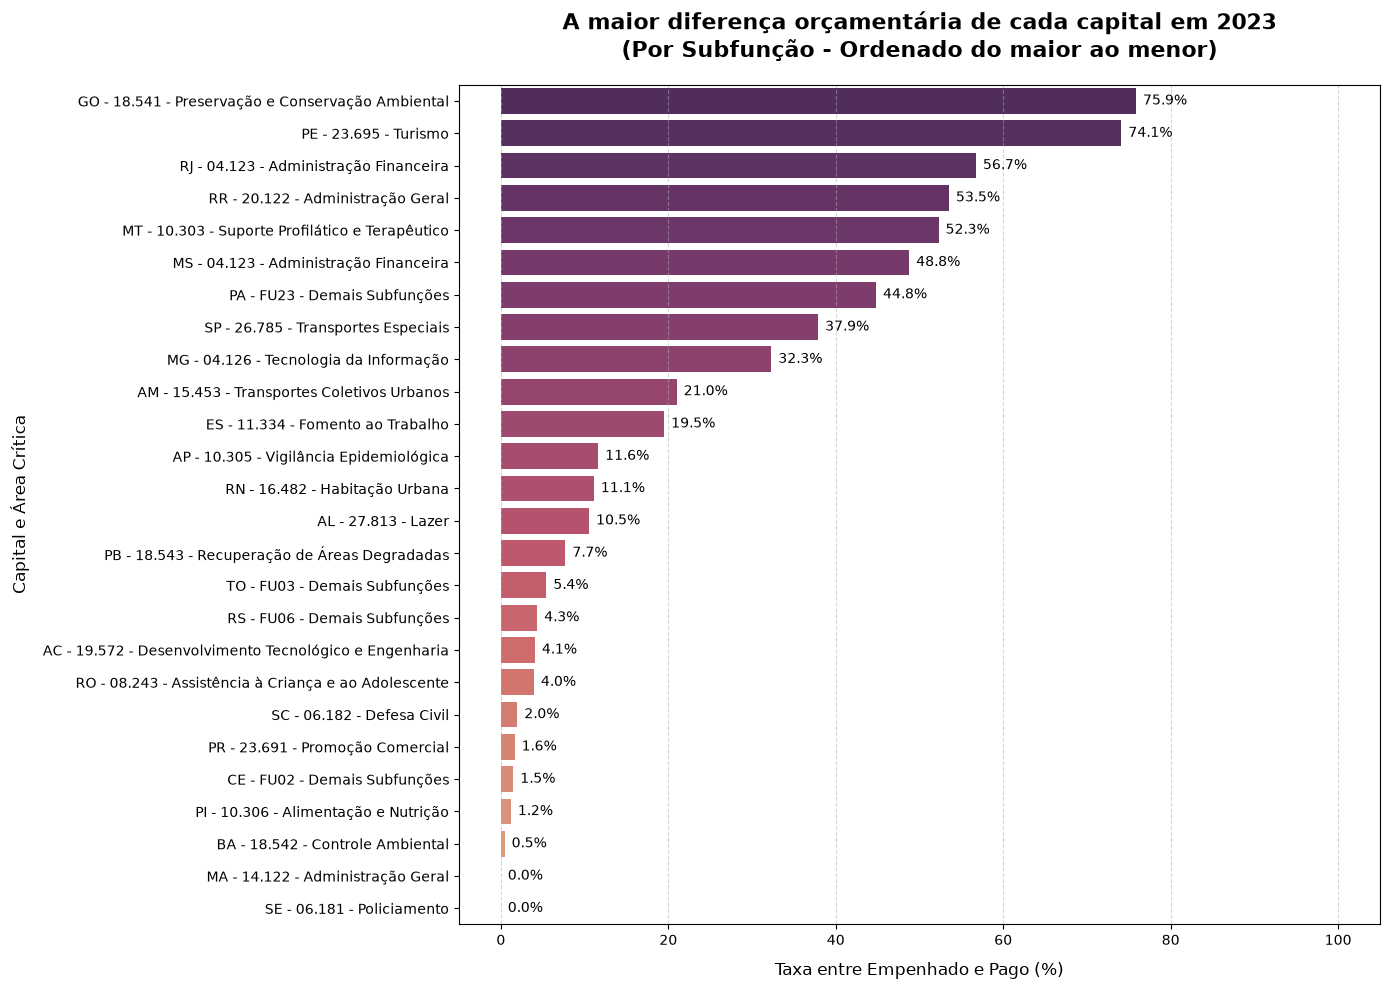

In [9]:
# Analisando o ano de 2023
grafico_menor_subfuncao(df_pivot, 2023)

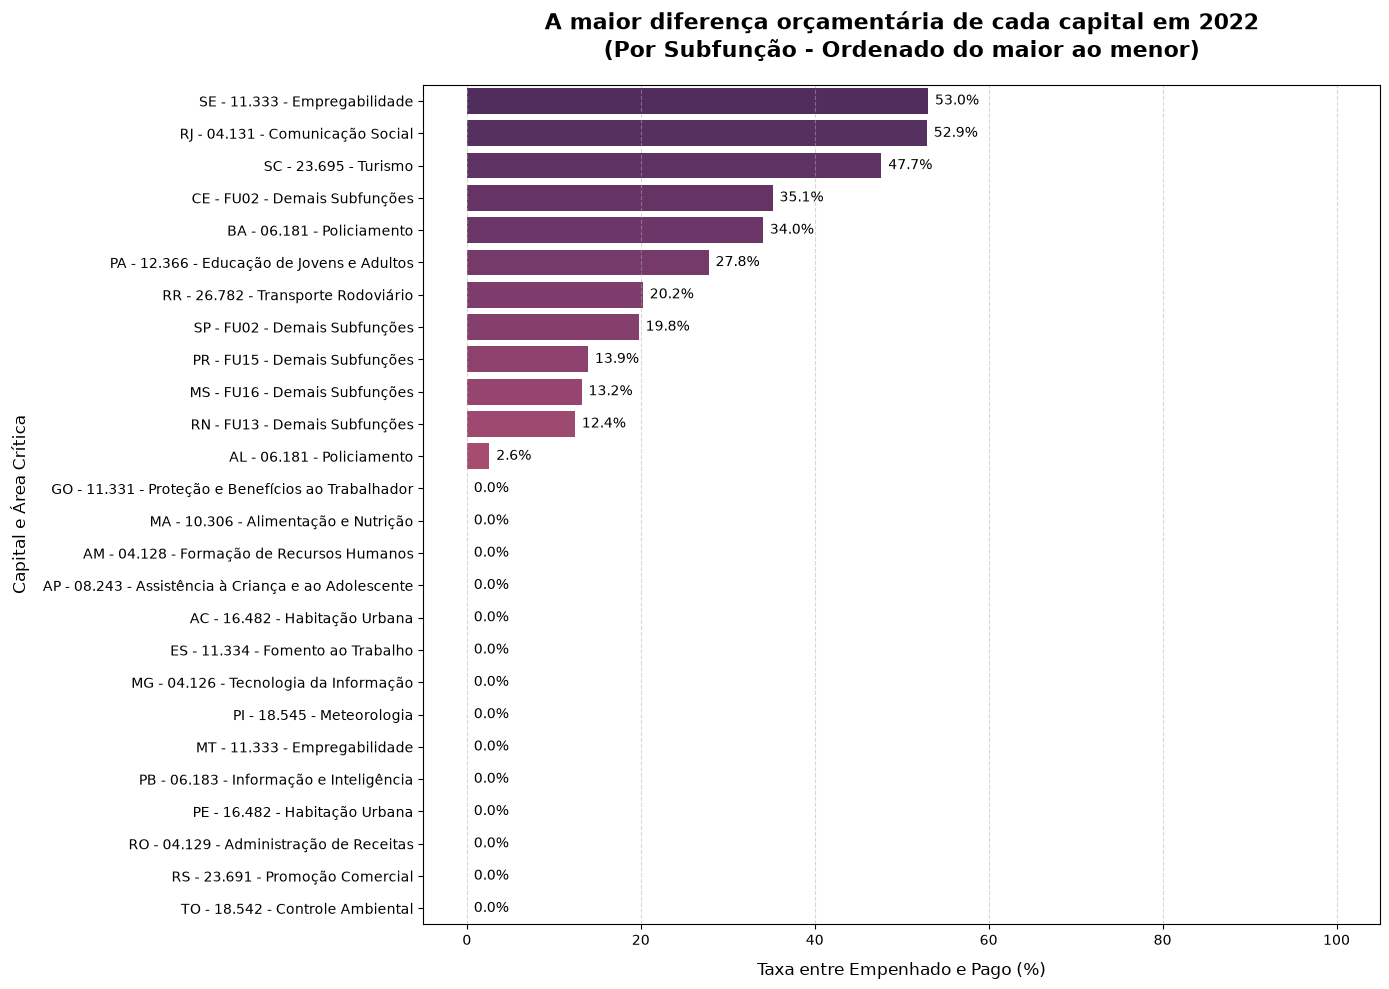

In [10]:
# Analisando o ano de 2022
grafico_menor_subfuncao(df_pivot, 2022)

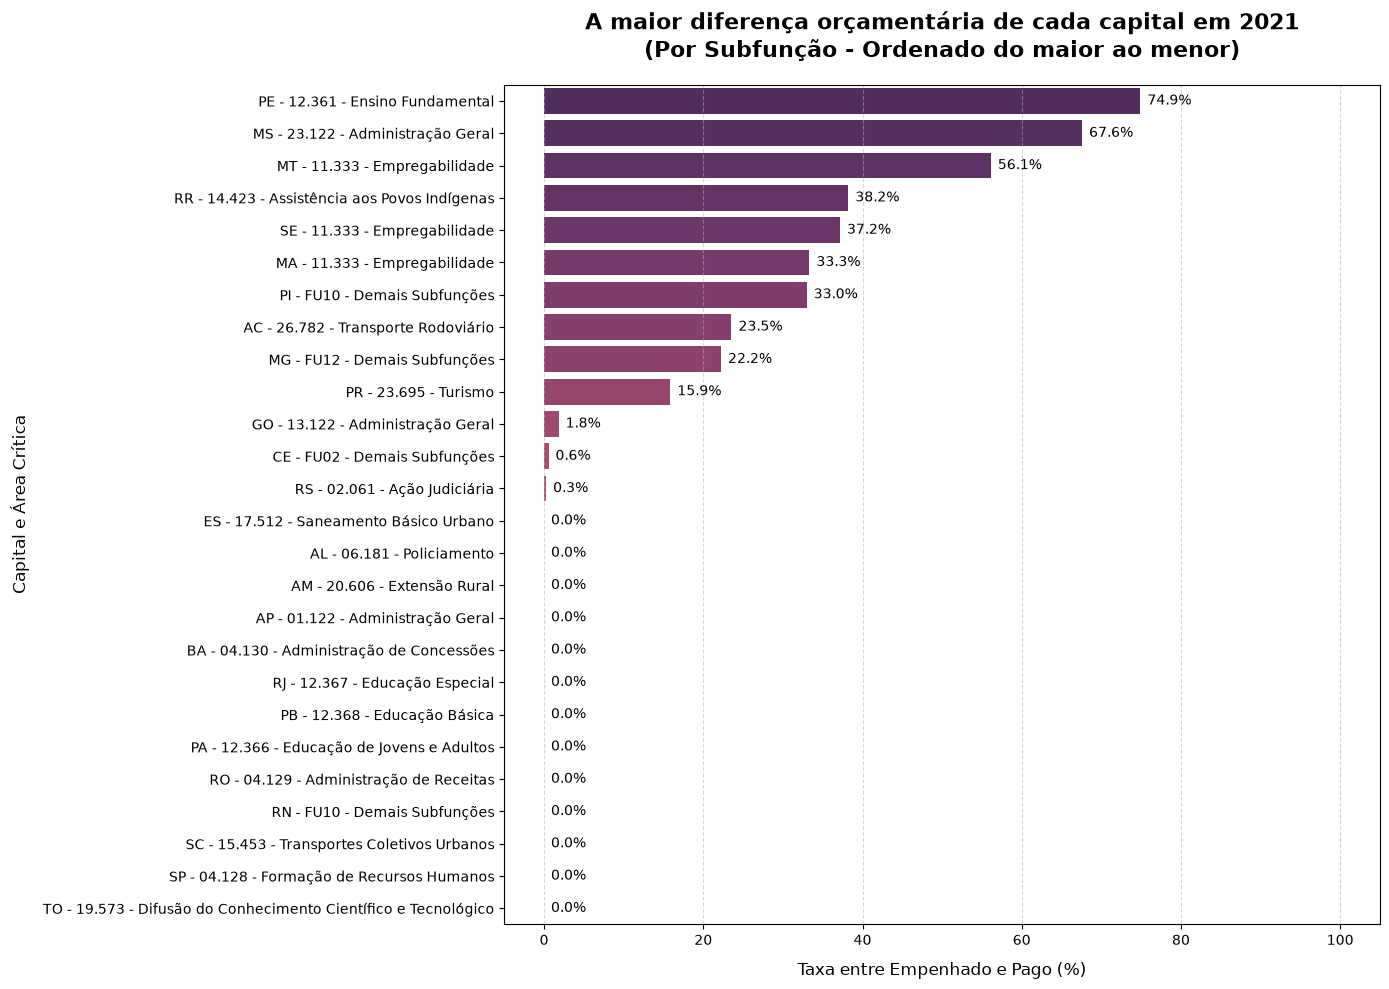

In [11]:
# Analisando o ano de 2021
grafico_menor_subfuncao(df_pivot, 2021)

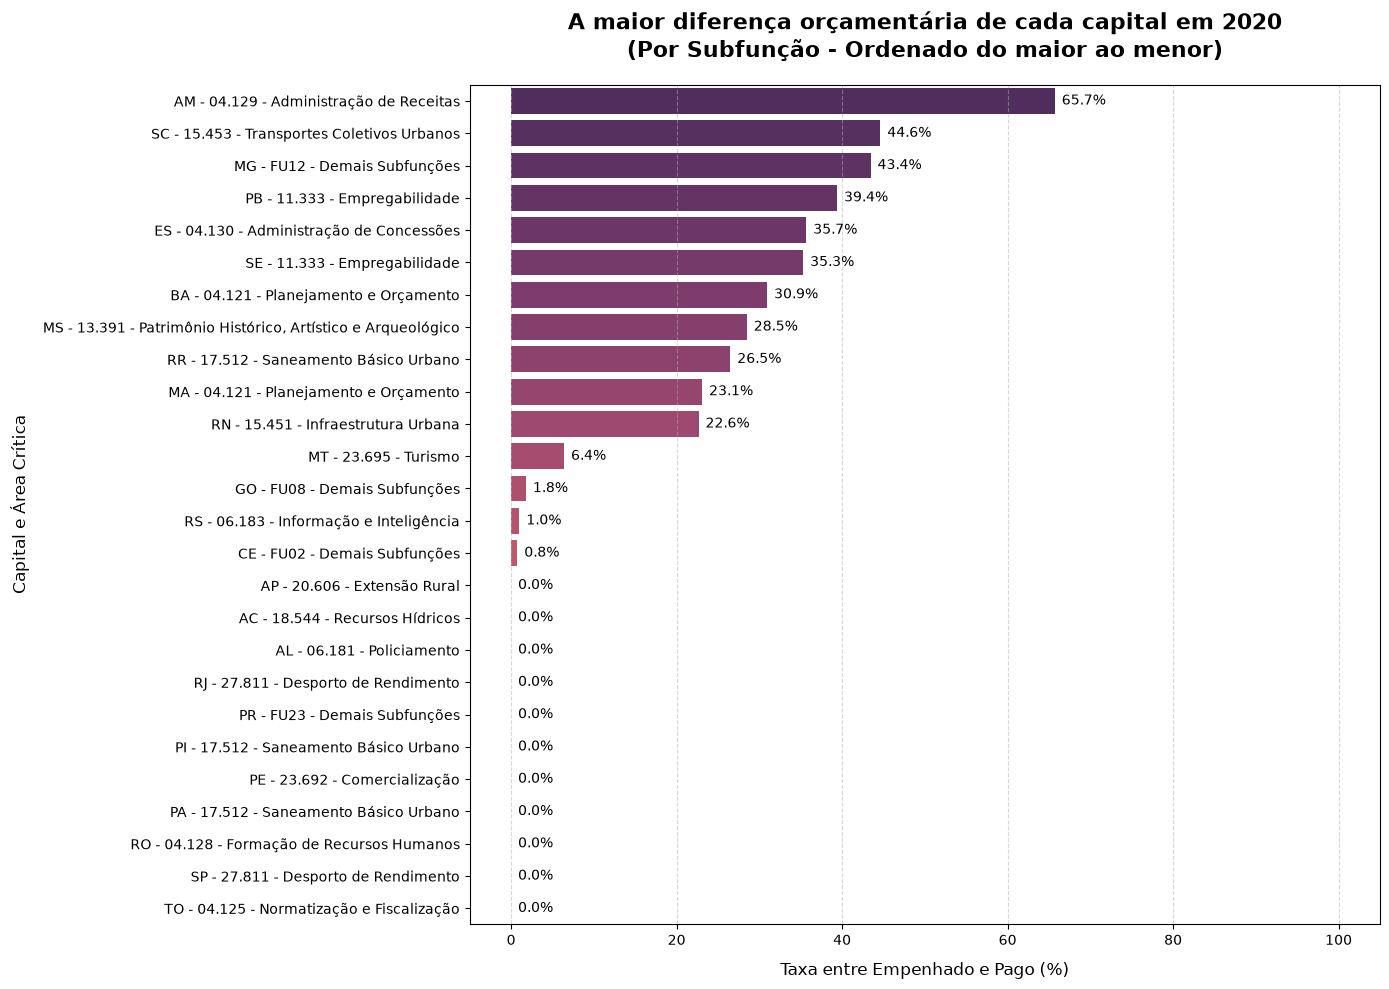

In [12]:
# Analisando o ano de 2020
grafico_menor_subfuncao(df_pivot, 2020)

Melhor análise em [README](./README.md)